In [7]:
import os
import cv2
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

import tensorflow as tf

from sklearn.metrics import (
    confusion_matrix,
    classification_report,
    roc_curve,
    auc
)

from sklearn.preprocessing import label_binarize

from tensorflow.keras.preprocessing.image import ImageDataGenerator

from tensorflow.keras.models import Sequential, Model

from tensorflow.keras.layers import (
    Conv2D,
    MaxPooling2D,
    Flatten,
    Dense,
    Dropout,
    GlobalAveragePooling2D
)

from tensorflow.keras.callbacks import EarlyStopping

In [8]:
train_path = "C:\\Rice-Leaf-Disease-Classification\\dataset\\train"

print(os.listdir(train_path))

['BrownSpot', 'Healthy', 'Hispa', 'LeafBlast']


In [9]:
dataset_info = []

for cls in os.listdir(train_path):

    class_path = os.path.join(
        train_path,
        cls
    )

    count = len(
        os.listdir(class_path)
    )

    dataset_info.append(
        [cls,count]
    )

dataset_df = pd.DataFrame(
    dataset_info,
    columns=["Class","Images"]
)

dataset_df

,Class,Images
0,BrownSpot,400
1,Healthy,400
2,Hispa,400
3,LeafBlast,400


In [10]:
dataset_df.to_csv(
    "C:\\Rice-Leaf-Disease-Classification\\outputs\\reports\\dataset_summary.csv",
    index=False
)

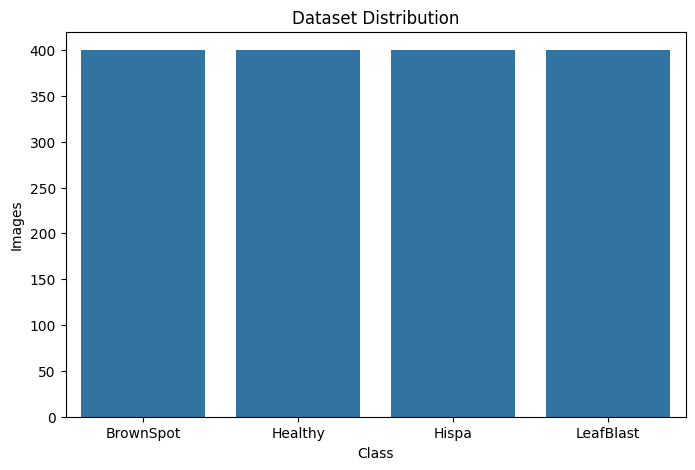

In [11]:
plt.figure(figsize=(8,5))

sns.barplot(
    data=dataset_df,
    x="Class",
    y="Images"
)

plt.title(
    "Dataset Distribution"
)

plt.savefig(
    "C:\\Rice-Leaf-Disease-Classification\\outputs\\figures\\dataset_distribution.png"
)

plt.show()

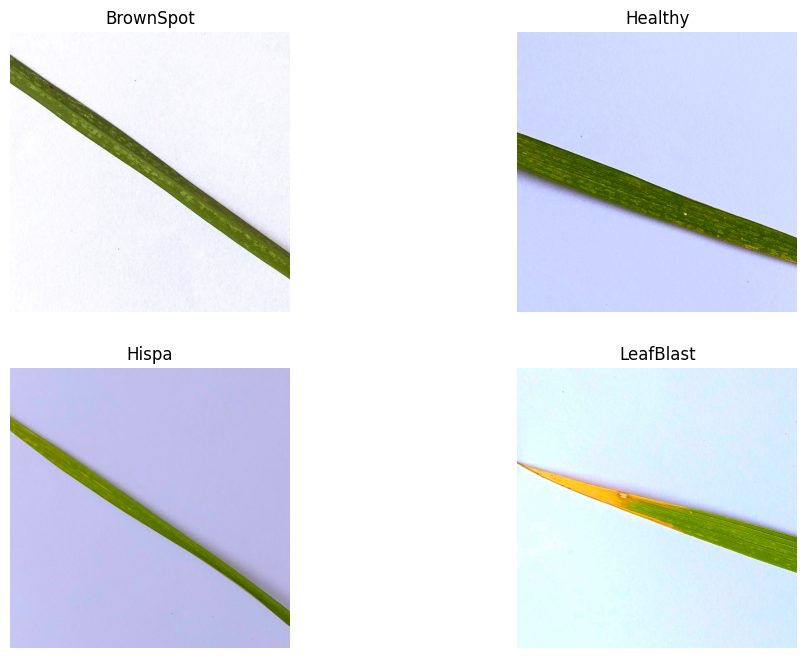

<Figure size 640x480 with 0 Axes>

In [12]:
plt.figure(figsize=(12,8))

for i, cls in enumerate(os.listdir(train_path)):

    image_name = os.listdir(
        os.path.join(train_path, cls)
    )[0]

    image_path = os.path.join(
        train_path,
        cls,
        image_name
    )

    img = cv2.imread(image_path)

    img = cv2.cvtColor(
        img,
        cv2.COLOR_BGR2RGB
    )

    plt.subplot(2,2,i+1)

    plt.imshow(img)

    plt.title(cls)

    plt.axis("off")

plt.show()
plt.savefig("C:\\Rice-Leaf-Disease-Classification\\outputs\\figures\\dataset_sampleimages.png")

In [13]:
import shutil
from sklearn.model_selection import train_test_split

In [14]:
train_datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=20,
    zoom_range=0.2,
    horizontal_flip=True,
    width_shift_range=0.1,
    height_shift_range=0.1,
    validation_split=0.2
)

test_datagen = ImageDataGenerator(
    rescale=1./255
)

In [15]:
train_generator = train_datagen.flow_from_directory(
    train_path,
    target_size=(224,224),
    batch_size=32,
    class_mode='categorical',
    subset='training'
)

validation_generator = train_datagen.flow_from_directory(
    train_path,
    target_size=(224,224),
    batch_size=32,
    class_mode='categorical',
    subset='validation',
    shuffle=False
)

Found 1280 images belonging to 4 classes.


Found 320 images belonging to 4 classes.


In [16]:
cnn_model = Sequential([

    Conv2D(
        32,
        (3,3),
        activation='relu',
        input_shape=(224,224,3)
    ),

    MaxPooling2D(),

    Conv2D(
        64,
        (3,3),
        activation='relu'
    ),

    MaxPooling2D(),

    Conv2D(
        128,
        (3,3),
        activation='relu'
    ),

    MaxPooling2D(),

    Flatten(),

    Dense(
        256,
        activation='relu'
    ),

    Dropout(0.5),

    Dense(
        4,
        activation='softmax'
    )
])

cnn_model.summary()

c:\Users\manik\AppData\Local\Programs\Python\Python312\Lib\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 222, 222, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 111, 111, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 109, 109, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 54, 54, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 52, 52, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 26, 26, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 86528)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │    22,151,424 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 4)              │         1,028 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 22,245,700 (84.86 MB)

 Trainable params: 22,245,700 (84.86 MB)

 Non-trainable params: 0 (0.00 B)

In [17]:
cnn_model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

In [18]:
early_stop = EarlyStopping(
    monitor='val_loss',
    patience=5,
    restore_best_weights=True
)

history = cnn_model.fit(
    train_generator,
    validation_data=validation_generator,
    epochs=20,
    callbacks=[early_stop]
)

Epoch 1/20
40/40 ━━━━━━━━━━━━━━━━━━━━ 118s 3s/step - accuracy: 0.2711 - loss: 1.6493 - val_accuracy: 0.2531 - val_loss: 1.3762
Epoch 2/20
40/40 ━━━━━━━━━━━━━━━━━━━━ 113s 3s/step - accuracy: 0.3484 - loss: 1.2816 - val_accuracy: 0.3438 - val_loss: 1.2915
Epoch 3/20
40/40 ━━━━━━━━━━━━━━━━━━━━ 137s 3s/step - accuracy: 0.4266 - loss: 1.1999 - val_accuracy: 0.3313 - val_loss: 1.2657
Epoch 4/20
40/40 ━━━━━━━━━━━━━━━━━━━━ 145s 4s/step - accuracy: 0.4172 - loss: 1.2056 - val_accuracy: 0.3125 - val_loss: 1.3694
Epoch 5/20
40/40 ━━━━━━━━━━━━━━━━━━━━ 190s 5s/step - accuracy: 0.4141 - loss: 1.2366 - val_accuracy: 0.3469 - val_loss: 1.3390
Epoch 6/20
40/40 ━━━━━━━━━━━━━━━━━━━━ 224s 6s/step - accuracy: 0.4219 - loss: 1.2122 - val_accuracy: 0.3094 - val_loss: 1.3821
Epoch 7/20
40/40 ━━━━━━━━━━━━━━━━━━━━ 225s 6s/step - accuracy: 0.4477 - loss: 1.1819 - val_accuracy: 0.3094 - val_loss: 1.3436
Epoch 8/20
40/40 ━━━━━━━━━━━━━━━━━━━━ 225s 6s/step - accuracy: 0.4453 - loss: 1.1684 - val_accuracy: 0.3344 - v

In [19]:
cnn_model.save(
    "C:\\Rice-Leaf-Disease-Classification\\outputs\\models\\custom_cnn.keras"
)

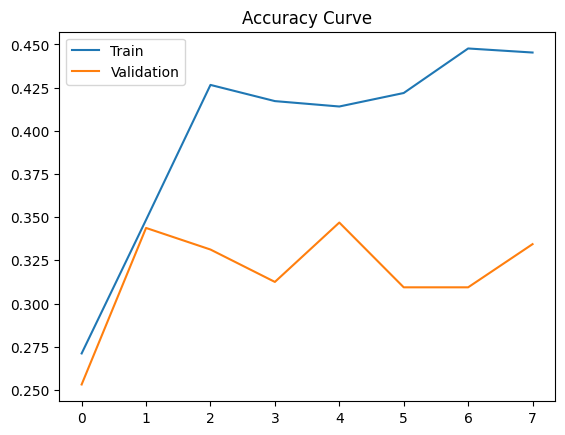

In [20]:
plt.plot(
    history.history['accuracy']
)

plt.plot(
    history.history['val_accuracy']
)

plt.legend(
    ['Train','Validation']
)

plt.title(
    'Accuracy Curve'
)

plt.savefig(
    'C:\\Rice-Leaf-Disease-Classification\\outputs\\figures\\accuracy_curve.png'
)

plt.show()

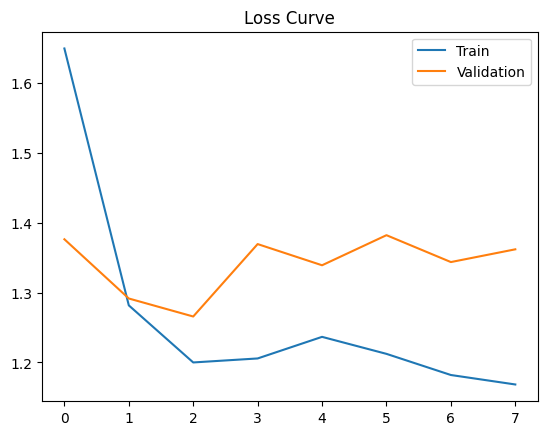

In [21]:
plt.plot(
    history.history['loss']
)

plt.plot(
    history.history['val_loss']
)

plt.legend(
    ['Train','Validation']
)

plt.title(
    'Loss Curve'
)

plt.savefig(
    'C:\\Rice-Leaf-Disease-Classification\\outputs\\figures\\loss_curve.png'
)

plt.show()

In [22]:
predictions = cnn_model.predict(
    validation_generator
)

y_pred = np.argmax(
    predictions,
    axis=1
)

y_true = validation_generator.classes

10/10 ━━━━━━━━━━━━━━━━━━━━ 41s 4s/step


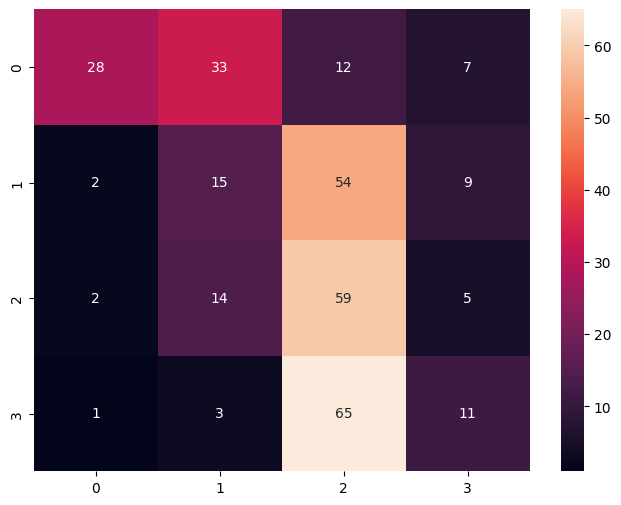

In [23]:
cm = confusion_matrix(
    y_true,
    y_pred
)

plt.figure(figsize=(8,6))

sns.heatmap(
    cm,
    annot=True,
    fmt='d'
)

plt.savefig(
    "C:\\Rice-Leaf-Disease-Classification\\outputs\\figures\\confusion_matrix.png"
)

plt.show()

In [24]:
report = classification_report(
    y_true,
    y_pred,
    target_names=list(
        train_generator.class_indices.keys()
    )
)

print(report)

with open(
    "C:\\Rice-Leaf-Disease-Classification\\outputs\\reports\\classification_report.txt",
    "w"
) as f:

    f.write(report)

              precision    recall  f1-score   support

   BrownSpot       0.85      0.35      0.50        80
     Healthy       0.23      0.19      0.21        80
       Hispa       0.31      0.74      0.44        80
   LeafBlast       0.34      0.14      0.20        80

    accuracy                           0.35       320
   macro avg       0.43      0.35      0.33       320
weighted avg       0.43      0.35      0.33       320



In [25]:
from tensorflow.keras.applications import MobileNetV2

base_model = MobileNetV2(
    weights='imagenet',
    include_top=False,
    input_shape=(224,224,3)
)

base_model.trainable = False

In [26]:
x = GlobalAveragePooling2D()(
    base_model.output
)

output = Dense(
    4,
    activation='softmax'
)(x)

mobilenet_model = Model(
    base_model.input,
    output
)

mobilenet_model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

mobilenet_history = mobilenet_model.fit(
    train_generator,
    validation_data=validation_generator,
    epochs=10
)

Epoch 1/10
40/40 ━━━━━━━━━━━━━━━━━━━━ 237s 6s/step - accuracy: 0.3422 - loss: 1.3805 - val_accuracy: 0.3219 - val_loss: 1.4267
Epoch 2/10
40/40 ━━━━━━━━━━━━━━━━━━━━ 217s 5s/step - accuracy: 0.4789 - loss: 1.1290 - val_accuracy: 0.3344 - val_loss: 1.4578
Epoch 3/10
40/40 ━━━━━━━━━━━━━━━━━━━━ 216s 5s/step - accuracy: 0.5227 - loss: 1.0868 - val_accuracy: 0.3844 - val_loss: 1.3468
Epoch 4/10
40/40 ━━━━━━━━━━━━━━━━━━━━ 219s 5s/step - accuracy: 0.5430 - loss: 1.0464 - val_accuracy: 0.3875 - val_loss: 1.3439
Epoch 5/10
40/40 ━━━━━━━━━━━━━━━━━━━━ 167s 4s/step - accuracy: 0.5586 - loss: 1.0119 - val_accuracy: 0.3969 - val_loss: 1.4131
Epoch 6/10
40/40 ━━━━━━━━━━━━━━━━━━━━ 111s 3s/step - accuracy: 0.5797 - loss: 0.9845 - val_accuracy: 0.3688 - val_loss: 1.3512
Epoch 7/10
40/40 ━━━━━━━━━━━━━━━━━━━━ 117s 3s/step - accuracy: 0.5805 - loss: 0.9586 - val_accuracy: 0.3969 - val_loss: 1.4169
Epoch 8/10
40/40 ━━━━━━━━━━━━━━━━━━━━ 107s 3s/step - accuracy: 0.5883 - loss: 0.9653 - val_accuracy: 0.3500 - v

In [27]:
from tensorflow.keras.applications import EfficientNetB0

base_model = EfficientNetB0(
    weights='imagenet',
    include_top=False,
    input_shape=(224,224,3)
)

base_model.trainable = False

In [28]:
x = GlobalAveragePooling2D()(
    base_model.output
)

output = Dense(
    4,
    activation='softmax'
)(x)

efficient_model = Model(
    base_model.input,
    output
)

efficient_model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

efficient_history = efficient_model.fit(
    train_generator,
    validation_data=validation_generator,
    epochs=10
)

Epoch 1/10
40/40 ━━━━━━━━━━━━━━━━━━━━ 115s 3s/step - accuracy: 0.2375 - loss: 1.4022 - val_accuracy: 0.2500 - val_loss: 1.3968
Epoch 2/10
40/40 ━━━━━━━━━━━━━━━━━━━━ 104s 3s/step - accuracy: 0.2484 - loss: 1.4010 - val_accuracy: 0.2500 - val_loss: 1.3997
Epoch 3/10
40/40 ━━━━━━━━━━━━━━━━━━━━ 108s 3s/step - accuracy: 0.2430 - loss: 1.4102 - val_accuracy: 0.2500 - val_loss: 1.3934
Epoch 4/10
40/40 ━━━━━━━━━━━━━━━━━━━━ 106s 3s/step - accuracy: 0.2250 - loss: 1.3982 - val_accuracy: 0.2500 - val_loss: 1.3920
Epoch 5/10
40/40 ━━━━━━━━━━━━━━━━━━━━ 103s 3s/step - accuracy: 0.2578 - loss: 1.4008 - val_accuracy: 0.2500 - val_loss: 1.4143
Epoch 6/10
40/40 ━━━━━━━━━━━━━━━━━━━━ 104s 3s/step - accuracy: 0.2461 - loss: 1.4019 - val_accuracy: 0.2500 - val_loss: 1.4038
Epoch 7/10
40/40 ━━━━━━━━━━━━━━━━━━━━ 103s 3s/step - accuracy: 0.2414 - loss: 1.4078 - val_accuracy: 0.2500 - val_loss: 1.4038
Epoch 8/10
40/40 ━━━━━━━━━━━━━━━━━━━━ 104s 3s/step - accuracy: 0.2313 - loss: 1.4143 - val_accuracy: 0.2500 - v

In [ ]:
# ============================================================
# Generate and Save Custom CNN Architecture Diagram
# ============================================================

from tensorflow.keras.utils import plot_model
from tensorflow.keras.models import load_model
from IPython.display import Image, display
import os

model_to_plot = None

try:
    model_to_plot = cnn_model
except NameError:
    saved_model_path = "C:\\Rice-Leaf-Disease-Classification\\outputs\\models\\custom_cnn.keras"
    if os.path.exists(saved_model_path):
        model_to_plot = load_model(saved_model_path)
        print(f"Loaded saved model from {saved_model_path}")
    else:
        raise RuntimeError(
            "cnn_model is not defined and saved model file was not found. "
            "Rerun the training cells or restore the model before plotting."
        )

plot_model(
    model_to_plot,
    to_file="C:\\Rice-Leaf-Disease-Classification\\outputs\\figures\\custom_cnn_architecture.png",
    show_shapes=True,        # Show input/output tensor shapes
    show_dtype=False,
    show_layer_names=True,   # Display layer names
    rankdir="TB",            # Top to Bottom layout
    expand_nested=False,
    dpi=300
)

print("Custom CNN architecture saved successfully!")
print("Location: outputs/figures/custom_cnn_architecture.png")

display(Image(filename="C:\\Rice-Leaf-Disease-Classification\\outputs\\figures\\custom_cnn_architecture.png"))


NameError: name 'cnn_model' is not defined

In [37]:
comparison_df = pd.DataFrame({

    "Model":[
        "CNN",
        "MobileNetV2",
        "EfficientNetB0"
    ],

    "Validation Accuracy":[

        max(
            history.history['val_accuracy']
        ),

        max(
            mobilenet_history.history['val_accuracy']
        ),

        max(
            efficient_history.history['val_accuracy']
        )
    ]
})

comparison_df

,Model,Validation Accuracy
0,CNN,0.346875
1,MobileNetV2,0.396875
2,EfficientNetB0,0.250000


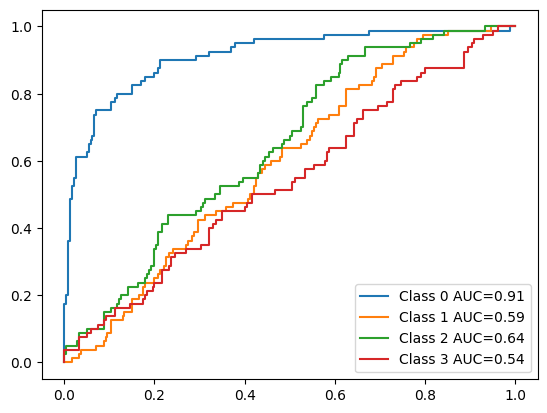

In [ ]:
y_true_bin = label_binarize(
    y_true,
    classes=[0,1,2,3]
)

for i in range(4):

    fpr,tpr,_ = roc_curve(
        y_true_bin[:,i],
        predictions[:,i]
    )

    roc_auc = auc(
        fpr,
        tpr
    )

    plt.plot(
        fpr,
        tpr,
        label=f'Class {i} AUC={roc_auc:.2f}'
    )

plt.legend()

plt.savefig(
    "C:\\Rice-Leaf-Disease-Classification\\outputs\\figures\\roc_curve.png"
)

plt.show()

In [ ]:
wrong_idx = np.where(
    y_true != y_pred
)[0]

error_df = pd.DataFrame({

    "Actual":[
        list(
            train_generator.class_indices.keys()
        )[y_true[i]]
        for i in wrong_idx
    ],

    "Predicted":[
        list(
            train_generator.class_indices.keys()
        )[y_pred[i]]
        for i in wrong_idx
    ]
})

error_df.to_csv(
    "C:\\Rice-Leaf-Disease-Classification\\outputs\\reports\\error_analysis.csv",
    index=False
)

error_df.head()

,Actual,Predicted
0,BrownSpot,Healthy
1,BrownSpot,Healthy
2,BrownSpot,Healthy
3,BrownSpot,Healthy
4,BrownSpot,Healthy


In [ ]:
for layer in cnn_model.layers:
    print(layer.name)

conv2d
max_pooling2d
conv2d_1
max_pooling2d_1
conv2d_2
max_pooling2d_2
flatten
dense
dropout
dense_1


In [ ]:
import tensorflow as tf

def make_gradcam_heatmap(
    img_array,
    cnn_model,
    last_conv_layer_name,
    pred_index=None
):

    grad_model = tf.keras.models.Model(
        inputs=cnn_model.inputs,
        outputs=[
            cnn_model.get_layer(
                last_conv_layer_name
            ).output,
            cnn_model.outputs[0]
        ]
    )

    with tf.GradientTape() as tape:

        conv_outputs, predictions = grad_model(
            img_array,
            training=False
        )

        if pred_index is None:

            pred_index = tf.argmax(
                predictions[0]
            )

        class_channel = predictions[
            :,
            pred_index
        ]

    grads = tape.gradient(
        class_channel,
        conv_outputs
    )

    pooled_grads = tf.reduce_mean(
        grads,
        axis=(0,1,2)
    )

    conv_outputs = conv_outputs[0]

    heatmap = tf.reduce_sum(
        conv_outputs * pooled_grads,
        axis=-1
    )

    heatmap = tf.maximum(
        heatmap,
        0
    )

    heatmap /= (
        tf.reduce_max(
            heatmap
        ) + 1e-10
    )

    return heatmap.numpy()

In [ ]:
cnn_model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 222, 222, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 111, 111, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 109, 109, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 54, 54, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 52, 52, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 26, 26, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 86528)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │    22,151,424 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 4)              │         1,028 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 66,737,102 (254.58 MB)

 Trainable params: 22,245,700 (84.86 MB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 44,491,402 (169.72 MB)

In [ ]:
correct_idx = np.where(
    y_true == y_pred
)[0]

sample_idx = correct_idx[0]

image_path = validation_generator.filepaths[
    sample_idx
]

img = cv2.imread(image_path)

img = cv2.cvtColor(
    img,
    cv2.COLOR_BGR2RGB
)

img_resized = cv2.resize(
    img,
    (224,224)
)

img_array = img_resized.astype(
    "float32"
) / 255.0

img_array = np.expand_dims(
    img_array,
    axis=0
)

heatmap = make_gradcam_heatmap(
    img_array,
    cnn_model,
    last_conv_layer_name="conv2d"
)



c:\Users\manik\AppData\Local\Programs\Python\Python312\Lib\site-packages\keras\src\models\functional.py:258: UserWarning: The structure of `inputs` doesn't match the expected structure.
Expected: ['keras_tensor']
Received: inputs=Tensor(shape=(1, 224, 224, 3))
  warnings.warn(msg)


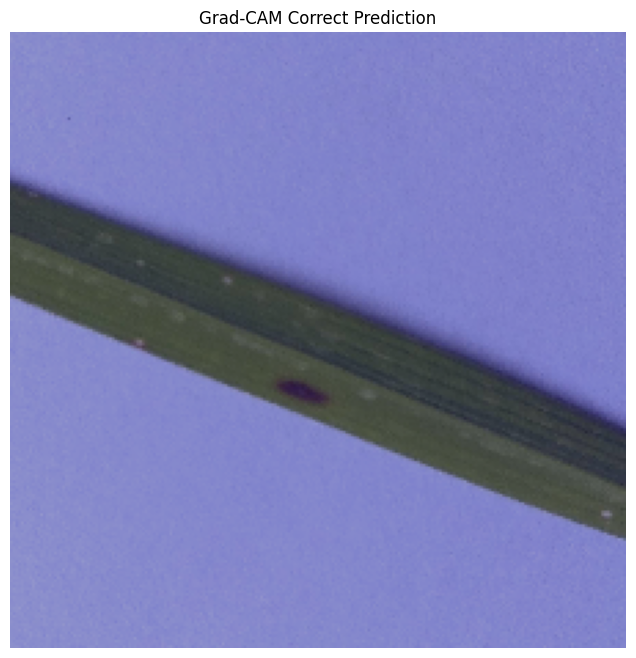

In [ ]:
heatmap = cv2.resize(
    heatmap,
    (224,224)
)

heatmap = np.uint8(
    255 * heatmap
)

heatmap_color = cv2.applyColorMap(
    heatmap,
    cv2.COLORMAP_JET
)

superimposed_img = cv2.addWeighted(
    cv2.cvtColor(
        img_resized,
        cv2.COLOR_RGB2BGR
    ),
    0.6,
    heatmap_color,
    0.4,
    0
)

plt.figure(figsize=(8,8))

plt.imshow(
    cv2.cvtColor(
        superimposed_img,
        cv2.COLOR_BGR2RGB
    )
)

plt.title(
    "Grad-CAM Correct Prediction"
)

plt.axis("off")

plt.savefig(
    "C:\\Rice-Leaf-Disease-Classification\\outputs\\figures\\gradcam_correct.png",
    bbox_inches="tight"
)

plt.show()

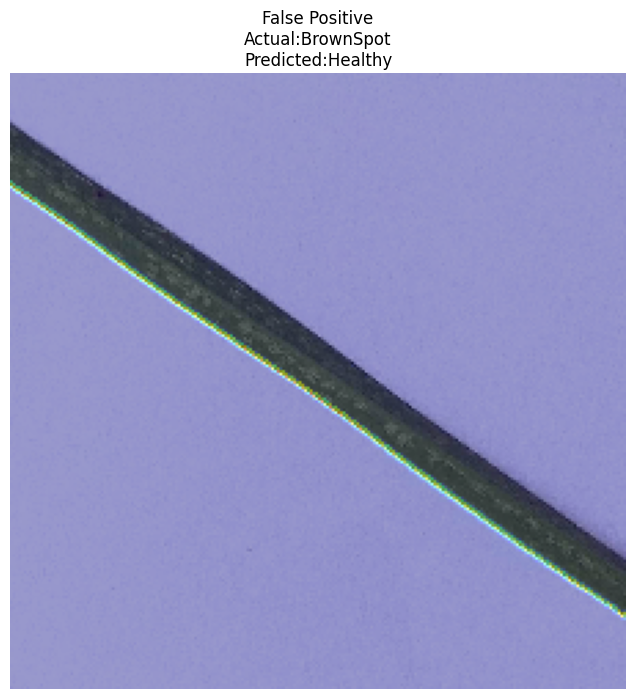

In [ ]:
wrong_idx = np.where(
    y_true != y_pred
)[0]

sample_idx = wrong_idx[0]

image_path = validation_generator.filepaths[
    sample_idx
]

img = cv2.imread(image_path)

img = cv2.cvtColor(
    img,
    cv2.COLOR_BGR2RGB
)

img_resized = cv2.resize(
    img,
    (224,224)
)

img_array = img_resized.astype(
    "float32"
) / 255.0

img_array = np.expand_dims(
    img_array,
    axis=0
)

heatmap = make_gradcam_heatmap(
    img_array,
    cnn_model,
    last_conv_layer_name="conv2d",
)

heatmap = cv2.resize(
    heatmap,
    (224,224)
)

heatmap = np.uint8(
    255 * heatmap
)

heatmap_color = cv2.applyColorMap(
    heatmap,
    cv2.COLORMAP_JET
)

superimposed_img = cv2.addWeighted(
    cv2.cvtColor(
        img_resized,
        cv2.COLOR_RGB2BGR
    ),
    0.6,
    heatmap_color,
    0.4,
    0
)

plt.figure(figsize=(8,8))

plt.imshow(
    cv2.cvtColor(
        superimposed_img,
        cv2.COLOR_BGR2RGB
    )
)

actual = list(
    train_generator.class_indices.keys()
)[y_true[sample_idx]]

predicted = list(
    train_generator.class_indices.keys()
)[y_pred[sample_idx]]

plt.title(
    f"False Positive\nActual:{actual}\nPredicted:{predicted}"
)

plt.axis("off")

plt.savefig(
    "C:\\Rice-Leaf-Disease-Classification\\outputs\\figures\\gradcam_false_positive.png",
    bbox_inches="tight"
)

plt.show()

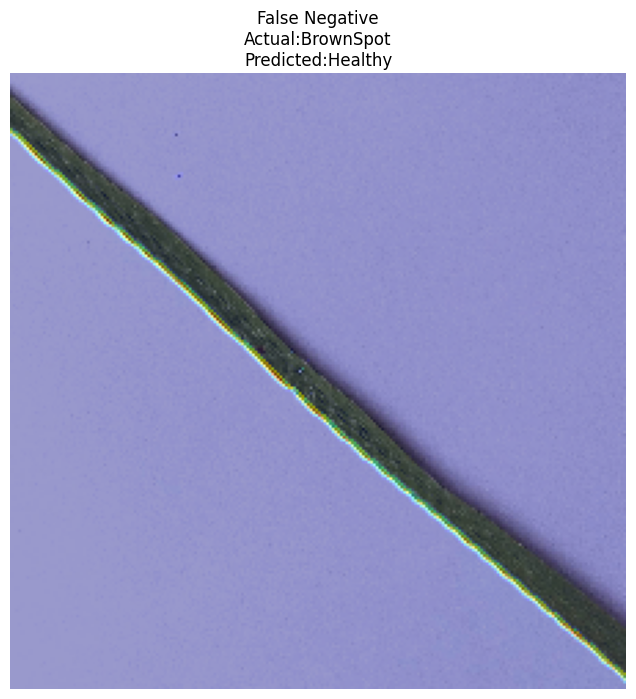

In [ ]:
sample_idx = wrong_idx[1]

image_path = validation_generator.filepaths[
    sample_idx
]

img = cv2.imread(image_path)

img = cv2.cvtColor(
    img,
    cv2.COLOR_BGR2RGB
)

img_resized = cv2.resize(
    img,
    (224,224)
)

img_array = img_resized.astype(
    "float32"
) / 255.0

img_array = np.expand_dims(
    img_array,
    axis=0
)

heatmap = make_gradcam_heatmap(
    img_array,
    cnn_model,
    last_conv_layer_name="conv2d",
)

heatmap = cv2.resize(
    heatmap,
    (224,224)
)

heatmap = np.uint8(
    255 * heatmap
)

heatmap_color = cv2.applyColorMap(
    heatmap,
    cv2.COLORMAP_JET
)

superimposed_img = cv2.addWeighted(
    cv2.cvtColor(
        img_resized,
        cv2.COLOR_RGB2BGR
    ),
    0.6,
    heatmap_color,
    0.4,
    0
)

plt.figure(figsize=(8,8))

plt.imshow(
    cv2.cvtColor(
        superimposed_img,
        cv2.COLOR_BGR2RGB
    )
)

actual = list(
    train_generator.class_indices.keys()
)[y_true[sample_idx]]

predicted = list(
    train_generator.class_indices.keys()
)[y_pred[sample_idx]]

plt.title(
    f"False Negative\nActual:{actual}\nPredicted:{predicted}"
)

plt.axis("off")

plt.savefig(
    "C:\\Rice-Leaf-Disease-Classification\\outputs\\figures\\gradcam_false_negative.png",
    bbox_inches="tight"
)

plt.show()